# 06 — Análisis de estructura del diseño

**Objetivo**: evaluar la **estructura factorial** del diseño experimental implícito en los datos, diagnosticando el balance entre celdas, la existencia de combinaciones vacías y las implicaciones para la estrategia analítica posterior.

### ¿Por qué este notebook?

Antes de ejecutar cualquier modelo estadístico (ANOVA, GLMM), es imprescindible comprender la estructura del diseño:

1. **Balance del diseño**: un diseño desbalanceado invalida el uso de sumas de cuadrados Tipo I y obliga a justificar la elección entre Tipo II y Tipo III.
2. **Celdas vacías**: si existen combinaciones factoriales sin observaciones, las interacciones de orden superior no son estimables y los modelos pueden colapsar.
3. **Robustez inferencial**: la interpretación de efectos principales e interacciones depende críticamente de la estructura del diseño.

### Pipeline

| Notebook | Fase | Estado |
|:---|:---|:---|
| 01 | Limpieza de negocio | ✅ |
| 02 | Selección de VD | ✅ |
| 03 | Métricas derivadas | ✅ |
| 04 | Limpieza estadística | ✅ |
| 05 | Diccionario de métricas | ✅ |
| **06** | **Estructura del diseño** | 🔄 ← este notebook |

### Variables independientes (VI)

| Variable | Tipo | Descripción |
|:---|:---|:---|
| `Espacio` | VI tarea (2 niveles) | Dimensión del espacio de juego |
| `Agrupacion` | VI tarea (2 niveles) | Tamaño de los grupos |
| `Polaridad` | VI tarea (2 niveles) | Dirección del juego |
| `Equilibrio` | VI tarea (2 niveles) | Igualdad numérica entre equipos |
| `GrupoEdad` | VI contexto (5 niveles) | Categoría de edad del equipo |
| `NombreCorrecto` | Contexto (12 niveles) | Equipo/categoría específica |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ── Estilo global ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

PALETTE = {
    "azul":    "#1565C0",
    "rojo":    "#C62828",
    "verde":   "#2E7D32",
    "naranja": "#EF6C00",
    "gris":    "#616161",
    "morado":  "#6A1B9A",
}

# ── Variables del diseño ──
VI_TAREA = ["Espacio", "Agrupacion", "Polaridad", "Equilibrio"]
VI_CONTEXTO = ["GrupoEdad", "NombreCorrecto"]
VI_ALL = VI_TAREA + VI_CONTEXTO

# ── Carga ──
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
N = len(df)
print(f"✅ Matriz_V3 cargada — {N:,} filas × {df.shape[1]} columnas")
print(f"\nVI de tarea:    {VI_TAREA}")
print(f"VI de contexto: {VI_CONTEXTO}")

✅ Matriz_V3 cargada — 4,446 filas × 19 columnas

VI de tarea:    ['Espacio', 'Agrupacion', 'Polaridad', 'Equilibrio']
VI de contexto: ['GrupoEdad', 'NombreCorrecto']


---

## 1 · Distribución marginal de cada VI

Se analiza la frecuencia absoluta y relativa de cada nivel de las 4 variables independientes de tarea. Un diseño balanceado debería mostrar proporciones similares entre niveles de cada factor.

In [2]:
# ── 1.1 Tablas de frecuencia marginal ──
print("═" * 65)
print("  DISTRIBUCIÓN MARGINAL — Variables independientes de tarea")
print("═" * 65)

for vi in VI_TAREA:
    vc = df[vi].value_counts()
    pct = df[vi].value_counts(normalize=True) * 100
    tabla = pd.DataFrame({"N": vc, "%": pct.round(1)})
    tabla.index.name = vi
    print(f"\n{'─'*60}")
    print(f"  {vi}  ({df[vi].nunique()} niveles)")
    print(f"{'─'*60}")
    for nivel in tabla.index:
        print(f"    {str(nivel):25s}  {tabla.loc[nivel, 'N']:>5,}  ({tabla.loc[nivel, '%']:>5.1f}%)")
    
    # Ratio de desbalance: max/min
    ratio = vc.max() / vc.min()
    print(f"  Ratio max/min: {ratio:.2f}  {'✅ Equilibrado' if ratio < 1.5 else '⚠️ Desbalance moderado' if ratio < 3 else '🔴 Desbalance severo'}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN MARGINAL — Variables independientes de tarea
═════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  Espacio  (2 niveles)
────────────────────────────────────────────────────────────
    reducido                   2,294  ( 51.6%)
    amplio                     2,152  ( 48.4%)
  Ratio max/min: 1.07  ✅ Equilibrado

────────────────────────────────────────────────────────────
  Agrupacion  (2 niveles)
────────────────────────────────────────────────────────────
    grande                     2,293  ( 51.6%)
    pequeno                    2,153  ( 48.4%)
  Ratio max/min: 1.07  ✅ Equilibrado

────────────────────────────────────────────────────────────
  Polaridad  (2 niveles)
────────────────────────────────────────────────────────────
    Polarizado                 3,477  ( 78.2%)
    No_polarizado                969  ( 21.8%)
  Ratio m

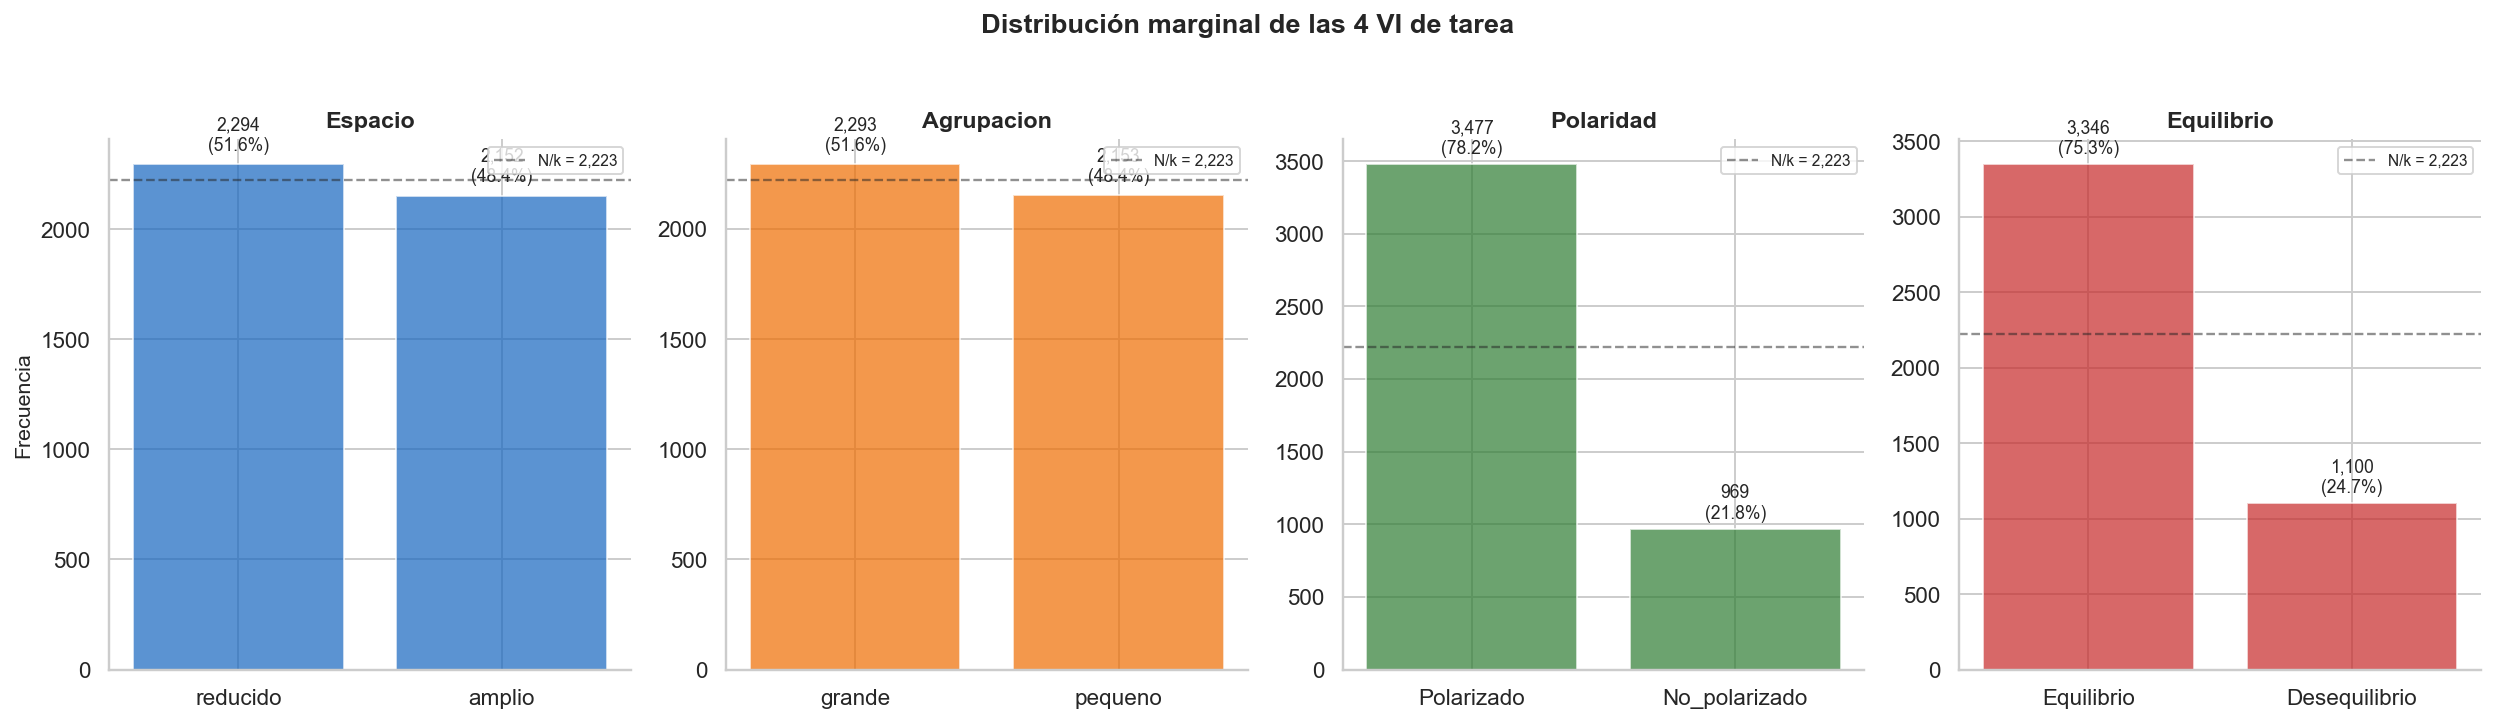

In [3]:
# ── 1.2 Barplots de distribución marginal ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colores = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]

for ax, vi, color in zip(axes, VI_TAREA, colores):
    vc = df[vi].value_counts()
    bars = ax.bar(vc.index, vc.values, color=color, alpha=0.7, edgecolor="white")
    
    # Etiquetas de frecuencia
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + N * 0.01,
                f"{val:,}\n({val/N*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    
    # Línea de referencia: N/k (distribución uniforme)
    k = df[vi].nunique()
    ax.axhline(N / k, color="#222", ls="--", lw=1.2, alpha=0.5,
               label=f"N/k = {N/k:,.0f}")
    
    ax.set_title(vi, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frecuencia" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución marginal de las 4 VI de tarea",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

---

## 2 · Tablas de contingencia cruzadas (diseño factorial)

Se generan las 6 tablas de contingencia posibles entre pares de VI de tarea, y la tabla factorial completa 4-way. El objetivo es detectar **celdas vacías** y evaluar el **grado de ortogonalidad** entre factores.

In [4]:
# ── 2.1–2.6 Tablas de contingencia 2-way ──
pares = list(combinations(VI_TAREA, 2))

print("═" * 65)
print("  TABLAS DE CONTINGENCIA 2-WAY")
print("═" * 65)

for i, (vi_a, vi_b) in enumerate(pares, 1):
    ct = pd.crosstab(df[vi_a], df[vi_b], margins=True, margins_name="Total")
    ct_pct = pd.crosstab(df[vi_a], df[vi_b], normalize="all") * 100
    
    n_celdas = df[vi_a].nunique() * df[vi_b].nunique()
    n_vacias = (ct.iloc[:-1, :-1] == 0).sum().sum()
    
    print(f"\n{'─'*65}")
    print(f"  2.{i}  {vi_a} × {vi_b}")
    print(f"{'─'*65}")
    print(f"  Combinaciones posibles: {n_celdas}")
    print(f"  Celdas vacías:          {n_vacias}  {'✅' if n_vacias == 0 else '⚠️'}")
    print()
    
    # Tabla con frecuencias absolutas
    display(ct)
    
    # Ratio max/min dentro de las celdas (excluyendo marginales)
    vals = ct.iloc[:-1, :-1].values.flatten()
    vals_nonzero = vals[vals > 0]
    if len(vals_nonzero) > 1:
        ratio = vals_nonzero.max() / vals_nonzero.min()
        print(f"  Ratio max/min entre celdas: {ratio:.2f}")
        print(f"  CV del tamaño de celda:     {np.std(vals_nonzero)/np.mean(vals_nonzero)*100:.1f}%")

═════════════════════════════════════════════════════════════════
  TABLAS DE CONTINGENCIA 2-WAY
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  2.1  Espacio × Agrupacion
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Agrupacion,grande,pequeno,Total
Espacio,,,
amplio,1662,490,2152
reducido,631,1663,2294
Total,2293,2153,4446


  Ratio max/min entre celdas: 3.39
  CV del tamaño de celda:     49.8%

─────────────────────────────────────────────────────────────────
  2.2  Espacio × Polaridad
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Polaridad,No_polarizado,Polarizado,Total
Espacio,,,
amplio,182,1970,2152
reducido,787,1507,2294
Total,969,3477,4446


  Ratio max/min entre celdas: 10.82
  CV del tamaño de celda:     61.4%

─────────────────────────────────────────────────────────────────
  2.3  Espacio × Equilibrio
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



...

  Ratio max/min entre celdas: 5.27
  CV del tamaño de celda:     58.2%

─────────────────────────────────────────────────────────────────
  2.5  Agrupacion × Equilibrio
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Equilibrio,Desequilibrio,Equilibrio,Total
Agrupacion,,,
grande,268,2025,2293
pequeno,832,1321,2153
Total,1100,3346,4446


  Ratio max/min entre celdas: 7.56
  CV del tamaño de celda:     58.1%

─────────────────────────────────────────────────────────────────
  2.6  Polaridad × Equilibrio
─────────────────────────────────────────────────────────────────
  Combinaciones posibles: 4
  Celdas vacías:          0  ✅



Equilibrio,Desequilibrio,Equilibrio,Total
Polaridad,,,
No_polarizado,645,324,969
Polarizado,455,3022,3477
Total,1100,3346,4446


  Ratio max/min entre celdas: 9.33
  CV del tamaño de celda:     99.8%


In [5]:
# ── 2.7 Tabla de contingencia 4-way completa ──
print("═" * 70)
print("  TABLA FACTORIAL COMPLETA: Espacio × Agrupacion × Polaridad × Equilibrio")
print("═" * 70)

# Calcular frecuencias por celda factorial
ct_4way = (
    df.groupby(VI_TAREA)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)

# Combinaciones posibles vs observadas
niveles_por_vi = [df[vi].nunique() for vi in VI_TAREA]
n_comb_posibles = np.prod(niveles_por_vi)
n_comb_observadas = len(ct_4way)
n_comb_vacias = n_comb_posibles - n_comb_observadas

print(f"\n  Niveles por factor: {dict(zip(VI_TAREA, niveles_por_vi))}")
print(f"  Combinaciones posibles:   {n_comb_posibles}")
print(f"  Combinaciones observadas: {n_comb_observadas}")
print(f"  Celdas vacías:            {n_comb_vacias}  "
      f"({n_comb_vacias/n_comb_posibles*100:.1f}%)  "
      f"{'✅ Diseño completo' if n_comb_vacias == 0 else '⚠️ Diseño incompleto'}")

print(f"\n{'─'*70}")
print(f"  Frecuencias por celda factorial")
print(f"{'─'*70}")
display(ct_4way)

# Estadísticos del tamaño de celda
ns = ct_4way["N"].values
print(f"\n  Estadísticos del tamaño de celda (N por combinación):")
print(f"    Media:    {np.mean(ns):>8.1f}")
print(f"    SD:       {np.std(ns):>8.1f}")
print(f"    Min:      {np.min(ns):>8}")
print(f"    Max:      {np.max(ns):>8}")
print(f"    CV:       {np.std(ns)/np.mean(ns)*100:>7.1f}%")
print(f"    Ratio max/min: {np.max(ns)/np.min(ns):.2f}")

══════════════════════════════════════════════════════════════════════
  TABLA FACTORIAL COMPLETA: Espacio × Agrupacion × Polaridad × Equilibrio
══════════════════════════════════════════════════════════════════════

  Niveles por factor: {'Espacio': 2, 'Agrupacion': 2, 'Polaridad': 2, 'Equilibrio': 2}
  Combinaciones posibles:   16
  Combinaciones observadas: 16
  Celdas vacías:            0  (0.0%)  ✅ Diseño completo

──────────────────────────────────────────────────────────────────────
  Frecuencias por celda factorial
──────────────────────────────────────────────────────────────────────


,Espacio,Agrupacion,Polaridad,Equilibrio,N
3,amplio,grande,Polarizado,Equilibrio,1461
15,reducido,pequeno,Polarizado,Equilibrio,806
12,reducido,pequeno,No_polarizado,Desequilibrio,435
11,reducido,grande,Polarizado,Equilibrio,385
7,amplio,pequeno,Polarizado,Equilibrio,370
14,reducido,pequeno,Polarizado,Desequilibrio,300
9,reducido,grande,No_polarizado,Equilibrio,124
13,reducido,pequeno,No_polarizado,Equilibrio,122
8,reducido,grande,No_polarizado,Desequilibrio,106
0,amplio,grande,No_polarizado,Desequilibrio,81



  Estadísticos del tamaño de celda (N por combinación):
    Media:       277.9
    SD:          368.7
    Min:            16
    Max:          1461
    CV:         132.7%
    Ratio max/min: 91.31


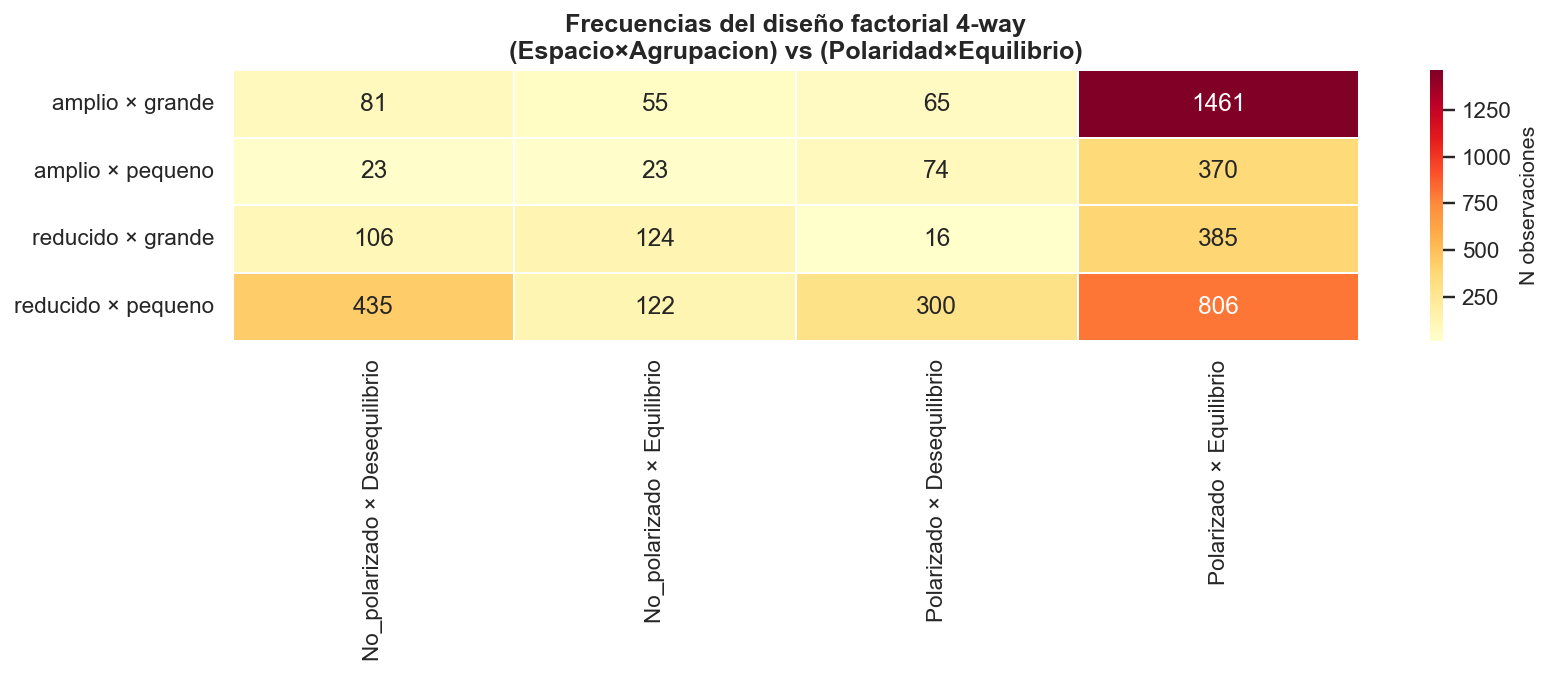

In [6]:
# ── 2.7b Heatmap de la tabla 4-way (pivotada para visualización) ──
ct_pivot = ct_4way.copy()
ct_pivot["Fila"] = ct_pivot["Espacio"] + " × " + ct_pivot["Agrupacion"]
ct_pivot["Columna"] = ct_pivot["Polaridad"] + " × " + ct_pivot["Equilibrio"]

heatmap_data = ct_pivot.pivot_table(index="Fila", columns="Columna", values="N",
                                     aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"label": "N observaciones"})
ax.set_title("Frecuencias del diseño factorial 4-way\n(Espacio×Agrupacion) vs (Polaridad×Equilibrio)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---

## 3 · Inclusión de GrupoEdad y NombreCorrecto

Se analiza la relación entre la variable de **contexto** (`GrupoEdad`, `NombreCorrecto`) y las 4 VI de tarea. El objetivo es evaluar:

1. Si todas las combinaciones factoriales se **replican** en todas las categorías de edad.
2. Si hay combinaciones **específicas** de ciertas categorías (diseño parcialmente anidado).
3. Si `GrupoEdad` y `NombreCorrecto` son redundantes o aportan información distinta.

In [7]:
# ── 3.1 Frecuencia por GrupoEdad ──
print("═" * 65)
print("  DISTRIBUCIÓN DE GrupoEdad")
print("═" * 65)

vc_ge = df["GrupoEdad"].value_counts()
for nivel, n in vc_ge.items():
    print(f"    {str(nivel):25s}  {n:>5,}  ({n/N*100:>5.1f}%)")

print(f"\n  Ratio max/min: {vc_ge.max()/vc_ge.min():.2f}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN DE GrupoEdad
═════════════════════════════════════════════════════════════════
    Neskak                     1,084  ( 24.4%)
    Senior Masculino           1,015  ( 22.8%)
    Juvenil                    1,006  ( 22.6%)
    Cadete                       716  ( 16.1%)
    Infantil                     625  ( 14.1%)

  Ratio max/min: 1.73


In [8]:
# ── 3.2 Frecuencia por NombreCorrecto ──
print("═" * 65)
print("  DISTRIBUCIÓN DE NombreCorrecto")
print("═" * 65)

vc_nc = df["NombreCorrecto"].value_counts()
for nivel, n in vc_nc.items():
    print(f"    {str(nivel):35s}  {n:>5,}  ({n/N*100:>5.1f}%)")

print(f"\n  Ratio max/min: {vc_nc.max()/vc_nc.min():.2f}")

═════════════════════════════════════════════════════════════════
  DISTRIBUCIÓN DE NombreCorrecto
═════════════════════════════════════════════════════════════════
    EASO                                   533  ( 12.0%)
    Juvenil División de Honor              473  ( 10.6%)
    Neskak A                               442  (  9.9%)
    Neskak B                               439  (  9.9%)
    Infantil Txiki                         413  (  9.3%)
    Real Sociedad C                        400  (  9.0%)
    Cadete Vasca                           361  (  8.1%)
    Cadete Txiki                           355  (  8.0%)
    SANSE                                  318  (  7.2%)
    Real Sociedad                          297  (  6.7%)
    Infantil Handi                         212  (  4.8%)
    Neskak C                               203  (  4.6%)

  Ratio max/min: 2.63


In [9]:
# ── 3.3 Relación GrupoEdad ↔ NombreCorrecto ──
print("═" * 65)
print("  RELACIÓN GrupoEdad ↔ NombreCorrecto")
print("═" * 65)

ct_ge_nc = pd.crosstab(df["NombreCorrecto"], df["GrupoEdad"])
display(ct_ge_nc)

# ¿Relación determinista? Cada NombreCorrecto mapea a un único GrupoEdad
mapeo = df.groupby("NombreCorrecto")["GrupoEdad"].nunique()
es_determinista = (mapeo == 1).all()
print(f"\n  ¿Mapeo determinista (1:1)? {'✅ Sí' if es_determinista else '❌ No'}")
print(f"  → NombreCorrecto está ANIDADO dentro de GrupoEdad.")
print(f"  → No deben incluirse ambos como factores cruzados en un mismo modelo.")
print(f"  → GrupoEdad = factor de agrupación; NombreCorrecto = nivel jerárquico inferior.")

═════════════════════════════════════════════════════════════════
  RELACIÓN GrupoEdad ↔ NombreCorrecto
═════════════════════════════════════════════════════════════════


GrupoEdad,Cadete,Infantil,Juvenil,Neskak,Senior Masculino
NombreCorrecto,,,,,
Cadete Txiki,355,0,0,0,0
Cadete Vasca,361,0,0,0,0
EASO,0,0,533,0,0
Infantil Handi,0,212,0,0,0
Infantil Txiki,0,413,0,0,0
Juvenil División de Honor,0,0,473,0,0
Neskak A,0,0,0,442,0
Neskak B,0,0,0,439,0
Neskak C,0,0,0,203,0



  ¿Mapeo determinista (1:1)? ✅ Sí
  → NombreCorrecto está ANIDADO dentro de GrupoEdad.
  → No deben incluirse ambos como factores cruzados en un mismo modelo.
  → GrupoEdad = factor de agrupación; NombreCorrecto = nivel jerárquico inferior.


In [10]:
# ── 3.4 Cruce GrupoEdad × cada VI de tarea ──
print("═" * 70)
print("  TABLAS DE CONTINGENCIA: GrupoEdad × VI de tarea")
print("═" * 70)

for vi in VI_TAREA:
    ct = pd.crosstab(df["GrupoEdad"], df[vi], margins=True, margins_name="Total")
    n_vacias = (ct.iloc[:-1, :-1] == 0).sum().sum()
    
    print(f"\n{'─'*65}")
    print(f"  GrupoEdad × {vi}")
    print(f"{'─'*65}")
    display(ct)
    print(f"  Celdas vacías: {n_vacias}  {'✅' if n_vacias == 0 else '⚠️'}")

══════════════════════════════════════════════════════════════════════
  TABLAS DE CONTINGENCIA: GrupoEdad × VI de tarea
══════════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  GrupoEdad × Espacio
─────────────────────────────────────────────────────────────────


Espacio,amplio,reducido,Total
GrupoEdad,,,
Cadete,351,365,716
Infantil,248,377,625
Juvenil,451,555,1006
Neskak,679,405,1084
Senior Masculino,423,592,1015
Total,2152,2294,4446


  Celdas vacías: 0  ✅

─────────────────────────────────────────────────────────────────
  GrupoEdad × Agrupacion
─────────────────────────────────────────────────────────────────


Agrupacion,grande,pequeno,Total
GrupoEdad,,,
Cadete,323,393,716
Infantil,395,230,625
Juvenil,358,648,1006
Neskak,802,282,1084
Senior Masculino,415,600,1015
Total,2293,2153,4446


  Celdas vacías: 0  ✅

─────────────────────────────────────────────────────────────────
  GrupoEdad × Polaridad
─────────────────────────────────────────────────────────────────


Polaridad,No_polarizado,Polarizado,Total
GrupoEdad,,,
Cadete,145,571,716
Infantil,132,493,625
Juvenil,194,812,1006
Neskak,216,868,1084
Senior Masculino,282,733,1015
Total,969,3477,4446


  Celdas vacías: 0  ✅

─────────────────────────────────────────────────────────────────
  GrupoEdad × Equilibrio
─────────────────────────────────────────────────────────────────


Equilibrio,Desequilibrio,Equilibrio,Total
GrupoEdad,,,
Cadete,217,499,716
Infantil,132,493,625
Juvenil,148,858,1006
Neskak,196,888,1084
Senior Masculino,407,608,1015
Total,1100,3346,4446


  Celdas vacías: 0  ✅


In [11]:
# ── 3.5 Tabla 5-way: GrupoEdad × diseño factorial 4-way ──
print("═" * 70)
print("  COBERTURA FACTORIAL POR GrupoEdad")
print("═" * 70)

ct_5way = df.groupby(["GrupoEdad"] + VI_TAREA).size().reset_index(name="N")

# Para cada GrupoEdad, ¿cuántas de las 16 combinaciones están representadas?
resumen_cobertura = []
for ge in sorted(df["GrupoEdad"].unique()):
    sub = ct_5way[ct_5way["GrupoEdad"] == ge]
    n_obs = sub["N"].sum()
    n_comb = len(sub)
    n_vacias = n_comb_posibles - n_comb
    resumen_cobertura.append({
        "GrupoEdad": ge,
        "N total": n_obs,
        "Combinaciones observadas": n_comb,
        "Combinaciones posibles": n_comb_posibles,
        "Celdas vacías": n_vacias,
        "Cobertura (%)": round(n_comb / n_comb_posibles * 100, 1),
        "N medio/celda": round(n_obs / n_comb, 1) if n_comb > 0 else 0,
    })

df_cobertura = pd.DataFrame(resumen_cobertura)
display(df_cobertura)

# ¿Diseño completo en todas las categorías?
todas_completas = (df_cobertura["Celdas vacías"] == 0).all()
print(f"\n  ¿Todas las categorías cubren las {n_comb_posibles} combinaciones? "
      f"{'✅ Sí' if todas_completas else '⚠️ No'}")

if not todas_completas:
    vacias = df_cobertura[df_cobertura["Celdas vacías"] > 0]
    for _, row in vacias.iterrows():
        print(f"    {row['GrupoEdad']}: {row['Celdas vacías']} celdas vacías "
              f"(cobertura {row['Cobertura (%)']}%)")

══════════════════════════════════════════════════════════════════════
  COBERTURA FACTORIAL POR GrupoEdad
══════════════════════════════════════════════════════════════════════


,GrupoEdad,N total,Combinaciones observadas,Combinaciones posibles,Celdas vacías,Cobertura (%),N medio/celda
0,Cadete,716,9,16,7,56.2,79.6
1,Infantil,625,12,16,4,75.0,52.1
2,Juvenil,1006,10,16,6,62.5,100.6
3,Neskak,1084,11,16,5,68.8,98.5
4,Senior Masculino,1015,12,16,4,75.0,84.6



  ¿Todas las categorías cubren las 16 combinaciones? ⚠️ No
    Cadete: 7 celdas vacías (cobertura 56.2%)
    Infantil: 4 celdas vacías (cobertura 75.0%)
    Juvenil: 6 celdas vacías (cobertura 62.5%)
    Neskak: 5 celdas vacías (cobertura 68.8%)
    Senior Masculino: 4 celdas vacías (cobertura 75.0%)


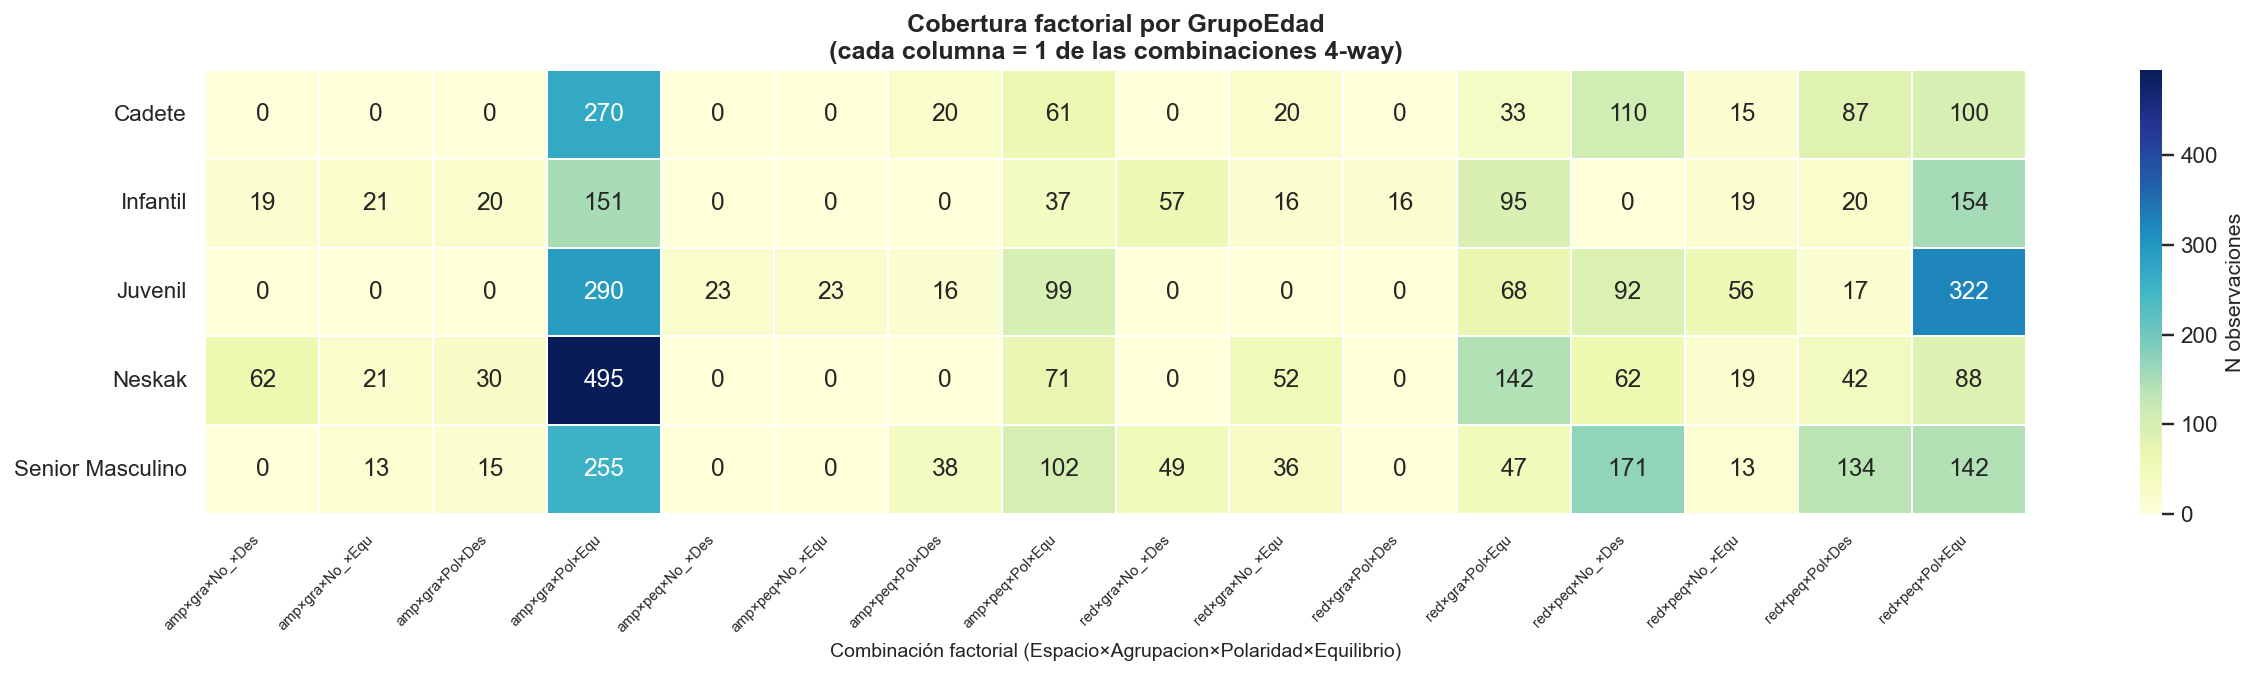


  Celdas con N=0 en el heatmap: 26/80 (32.5%)


In [12]:
# ── 3.6 Visualización: heatmap de cobertura por GrupoEdad ──
# Crear etiqueta de celda factorial para las 16 combinaciones
df_temp = df.copy()
df_temp["Celda_4way"] = (df_temp["Espacio"].str[:3] + "×" +
                          df_temp["Agrupacion"].str[:3] + "×" +
                          df_temp["Polaridad"].str[:3] + "×" +
                          df_temp["Equilibrio"].str[:3])

ct_heat = pd.crosstab(df_temp["GrupoEdad"], df_temp["Celda_4way"])

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(ct_heat, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=0.8, linecolor="white", ax=ax,
            cbar_kws={"label": "N observaciones"})
ax.set_title("Cobertura factorial por GrupoEdad\n(cada columna = 1 de las combinaciones 4-way)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Combinación factorial (Espacio×Agrupacion×Polaridad×Equilibrio)", fontsize=10)
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=7.5)
plt.tight_layout()
plt.show()

n_ceros_heatmap = (ct_heat == 0).sum().sum()
n_total_heatmap = ct_heat.shape[0] * ct_heat.shape[1]
print(f"\n  Celdas con N=0 en el heatmap: {n_ceros_heatmap}/{n_total_heatmap} "
      f"({n_ceros_heatmap/n_total_heatmap*100:.1f}%)")

---

## 4 · Evaluación formal del balance

Se cuantifica el grado de desbalance del diseño factorial utilizando métricas estándar. Un diseño **perfectamente balanceado** tiene todas las celdas con el mismo $N$; un diseño **desbalanceado** presenta variabilidad significativa.

In [13]:
# ── 4.1 Balance del diseño factorial 4-way (sin GrupoEdad) ──
print("═" * 70)
print("  EVALUACIÓN DEL BALANCE — Diseño 4-way")
print("═" * 70)

ns_4way = ct_4way["N"].values
n_esperado = N / n_comb_posibles

print(f"\n  Total de observaciones:        {N:,}")
print(f"  Celdas factoriales:            {n_comb_posibles}")
print(f"  N esperado (balanceado):       {n_esperado:.1f}")
print(f"\n  {'─'*50}")
print(f"  Estadísticos del tamaño de celda:")
print(f"    Media:        {np.mean(ns_4way):>8.1f}")
print(f"    SD:           {np.std(ns_4way, ddof=1):>8.1f}")
print(f"    Min:          {np.min(ns_4way):>8}")
print(f"    Max:          {np.max(ns_4way):>8}")
print(f"    Rango:        {np.max(ns_4way) - np.min(ns_4way):>8}")
print(f"    CV:           {np.std(ns_4way, ddof=1)/np.mean(ns_4way)*100:>7.1f}%")
print(f"    Ratio max/min:{np.max(ns_4way)/np.min(ns_4way):>7.2f}")

# Diagnóstico
cv_4way = np.std(ns_4way, ddof=1) / np.mean(ns_4way) * 100
if cv_4way < 5:
    diag = "✅ Diseño prácticamente balanceado (CV < 5%)"
elif cv_4way < 20:
    diag = "⚠️ Diseño moderadamente desbalanceado (5% < CV < 20%)"
else:
    diag = "🔴 Diseño severamente desbalanceado (CV > 20%)"

print(f"\n  DIAGNÓSTICO: {diag}")

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN DEL BALANCE — Diseño 4-way
══════════════════════════════════════════════════════════════════════

  Total de observaciones:        4,446
  Celdas factoriales:            16
  N esperado (balanceado):       277.9

  ──────────────────────────────────────────────────
  Estadísticos del tamaño de celda:
    Media:           277.9
    SD:              380.8
    Min:                16
    Max:              1461
    Rango:            1445
    CV:             137.0%
    Ratio max/min:  91.31

  DIAGNÓSTICO: 🔴 Diseño severamente desbalanceado (CV > 20%)


In [14]:
# ── 4.2 Balance del diseño factorial 5-way (incluyendo GrupoEdad) ──
print("═" * 70)
print("  EVALUACIÓN DEL BALANCE — Diseño 5-way (con GrupoEdad)")
print("═" * 70)

n_comb_5way_posibles = n_comb_posibles * df["GrupoEdad"].nunique()
ns_5way = ct_5way["N"].values
n_comb_5way_obs = len(ct_5way)
n_comb_5way_vacias = n_comb_5way_posibles - n_comb_5way_obs

print(f"\n  Combinaciones posibles (4 VI × GrupoEdad):  {n_comb_5way_posibles}")
print(f"  Combinaciones observadas:                    {n_comb_5way_obs}")
print(f"  Celdas vacías:                               {n_comb_5way_vacias} "
      f"({n_comb_5way_vacias/n_comb_5way_posibles*100:.1f}%)")

print(f"\n  {'─'*50}")
print(f"  Estadísticos del tamaño de celda:")
print(f"    Media:        {np.mean(ns_5way):>8.1f}")
print(f"    SD:           {np.std(ns_5way, ddof=1):>8.1f}")
print(f"    Min:          {np.min(ns_5way):>8}")
print(f"    Max:          {np.max(ns_5way):>8}")
print(f"    CV:           {np.std(ns_5way, ddof=1)/np.mean(ns_5way)*100:>7.1f}%")
print(f"    Ratio max/min:{np.max(ns_5way)/np.min(ns_5way):>7.2f}")

# Diagnóstico
cv_5way = np.std(ns_5way, ddof=1) / np.mean(ns_5way) * 100
if n_comb_5way_vacias > 0:
    diag_5 = f"⚠️ Diseño incompleto ({n_comb_5way_vacias} celdas vacías) y desbalanceado (CV = {cv_5way:.1f}%)"
elif cv_5way < 5:
    diag_5 = "✅ Diseño completo y prácticamente balanceado"
elif cv_5way < 20:
    diag_5 = f"⚠️ Diseño completo pero moderadamente desbalanceado (CV = {cv_5way:.1f}%)"
else:
    diag_5 = f"🔴 Diseño completo pero severamente desbalanceado (CV = {cv_5way:.1f}%)"

print(f"\n  DIAGNÓSTICO: {diag_5}")

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN DEL BALANCE — Diseño 5-way (con GrupoEdad)
══════════════════════════════════════════════════════════════════════

  Combinaciones posibles (4 VI × GrupoEdad):  80
  Combinaciones observadas:                    54
  Celdas vacías:                               26 (32.5%)

  ──────────────────────────────────────────────────
  Estadísticos del tamaño de celda:
    Media:            82.3
    SD:               93.5
    Min:                13
    Max:               495
    CV:             113.5%
    Ratio max/min:  38.08

  DIAGNÓSTICO: ⚠️ Diseño incompleto (26 celdas vacías) y desbalanceado (CV = 113.5%)


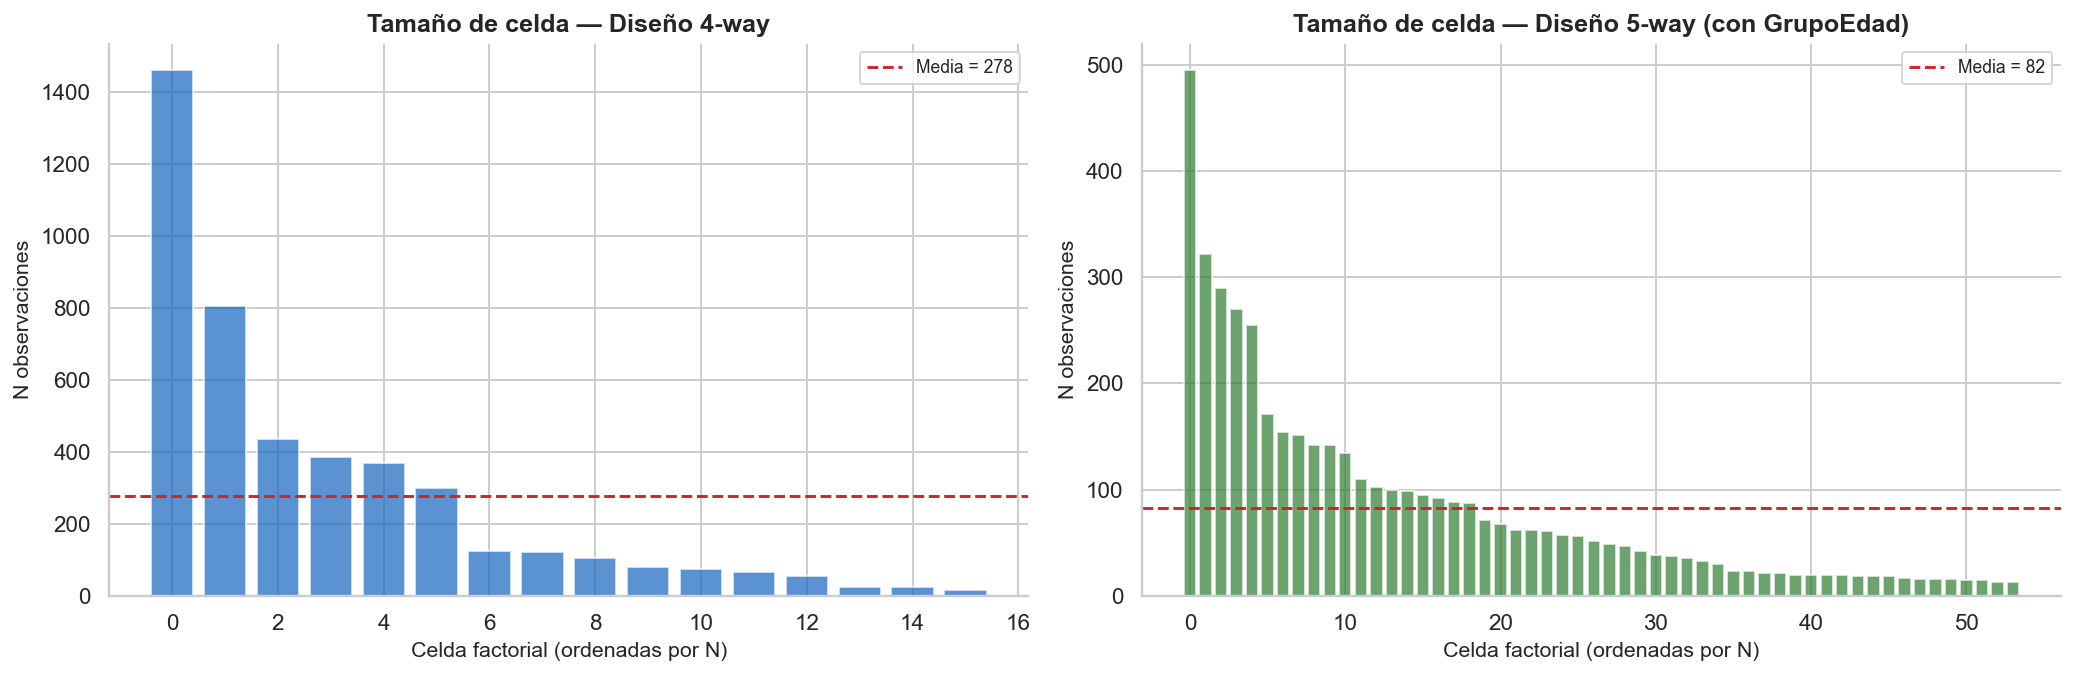

In [15]:
# ── 4.3 Visualización: distribución de tamaños de celda ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: 4-way
ax = axes[0]
ax.bar(range(len(ns_4way)), sorted(ns_4way, reverse=True),
       color=PALETTE["azul"], alpha=0.7, edgecolor="white")
ax.axhline(np.mean(ns_4way), color=PALETTE["rojo"], ls="--", lw=1.5,
           label=f"Media = {np.mean(ns_4way):.0f}")
ax.set_title("Tamaño de celda — Diseño 4-way", fontweight="bold")
ax.set_xlabel("Celda factorial (ordenadas por N)")
ax.set_ylabel("N observaciones")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Panel 2: 5-way (con GrupoEdad)
ax2 = axes[1]
ax2.bar(range(len(ns_5way)), sorted(ns_5way, reverse=True),
        color=PALETTE["verde"], alpha=0.7, edgecolor="white")
ax2.axhline(np.mean(ns_5way), color=PALETTE["rojo"], ls="--", lw=1.5,
            label=f"Media = {np.mean(ns_5way):.0f}")
ax2.set_title("Tamaño de celda — Diseño 5-way (con GrupoEdad)", fontweight="bold")
ax2.set_xlabel("Celda factorial (ordenadas por N)")
ax2.set_ylabel("N observaciones")
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
# ── 4.4 Resumen compacto del diagnóstico de balance ──
print("═" * 70)
print("  RESUMEN: DIAGNÓSTICO DE BALANCE DEL DISEÑO")
print("═" * 70)

resumen_balance = [
    {"Diseño": "4-way (VI tarea)",
     "Celdas posibles": n_comb_posibles,
     "Celdas observadas": n_comb_observadas,
     "Celdas vacías": n_comb_vacias,
     "N medio/celda": round(np.mean(ns_4way), 1),
     "CV (%)": round(cv_4way, 1),
     "Ratio max/min": round(np.max(ns_4way)/np.min(ns_4way), 2),
     "Completo": "✅" if n_comb_vacias == 0 else "❌",
     "Balanceado": "✅" if cv_4way < 5 else "⚠️" if cv_4way < 20 else "❌",
    },
    {"Diseño": "5-way (+ GrupoEdad)",
     "Celdas posibles": n_comb_5way_posibles,
     "Celdas observadas": n_comb_5way_obs,
     "Celdas vacías": n_comb_5way_vacias,
     "N medio/celda": round(np.mean(ns_5way), 1),
     "CV (%)": round(cv_5way, 1),
     "Ratio max/min": round(np.max(ns_5way)/np.min(ns_5way), 2),
     "Completo": "✅" if n_comb_5way_vacias == 0 else "❌",
     "Balanceado": "✅" if cv_5way < 5 else "⚠️" if cv_5way < 20 else "❌",
    },
]

df_balance = pd.DataFrame(resumen_balance)
display(df_balance.style.hide(axis="index"))

══════════════════════════════════════════════════════════════════════
  RESUMEN: DIAGNÓSTICO DE BALANCE DEL DISEÑO
══════════════════════════════════════════════════════════════════════


Diseño,Celdas posibles,Celdas observadas,Celdas vacías,N medio/celda,CV (%),Ratio max/min,Completo,Balanceado
4-way (VI tarea),16,16,0,277.900000,137.000000,91.310000,✅,❌
5-way (+ GrupoEdad),80,54,26,82.300000,113.500000,38.080000,❌,❌


---



## 5 · Implicaciones estadísticas



### 5.1. Sumas de cuadrados: Tipo I, II y III



En un ANOVA factorial, la descomposición de la variabilidad total en componentes atribuibles a cada factor depende del **tipo de sumas de cuadrados** (SS) utilizado. La elección entre Tipo I, II y III no es arbitraria: depende directamente de la **estructura del diseño**.



#### Tipo I — Sumas de cuadrados secuenciales



Cada factor se ajusta **tras controlar los factores introducidos antes** en la ecuación. El resultado depende del **orden** en que se especifiquen los factores.



- **Solo apropiado** en diseños **perfectamente balanceados** (todas las celdas con el mismo $N$), donde los tres tipos de SS coinciden.

- En diseños desbalanceados, los resultados cambian según el orden de los factores → **no recomendable**.



#### Tipo II — Sumas de cuadrados parciales (sin interacción)



Cada efecto principal se ajusta **controlando todos los demás efectos principales**, pero **sin considerar las interacciones**.



- Apropiado cuando se asume que **no existen interacciones** o cuando no se desea estimar interacciones.

- Más potente que el Tipo III cuando las interacciones son realmente nulas.

- **No recomendable** si:

  - Las interacciones son significativas (los efectos principales pierden interpretabilidad).

  - Existen celdas vacías (las estimaciones de efectos principales pueden estar sesgadas).



#### Tipo III — Sumas de cuadrados parciales (con interacción)



Cada efecto (principal o interacción) se ajusta **controlando todos los demás efectos**, incluidas las interacciones.



- El resultado es **invariante al orden** de los factores.

- Cada efecto se evalúa como la **reducción marginal de SS** al añadirlo al modelo completo.

- **Recomendable cuando**:

  - El diseño es **desbalanceado** (celdas con distinto $N$).

  - Se desean estimar **interacciones**.

  - Existen **celdas vacías** (aunque con precauciones).



---



### 5.2. ¿Qué significa Tipo III conceptualmente?



Las SS Tipo III responden a la pregunta:



> *¿Cuánta variabilidad explica este factor después de controlar todos los demás factores e interacciones del modelo?*



Formalmente, para un factor $A$ en un modelo con factores $A$, $B$ y su interacción $A \times B$:



$$

SS_{III}(A) = SS(A \mid B, A \times B)

$$



Es decir, el incremento en la suma de cuadrados del modelo al **añadir $A$** cuando $B$ y $A \times B$ ya están en el modelo. Esto garantiza que el efecto de $A$ no esté confundido con el desbalance de las otras variables.



En la práctica, las SS Tipo III requieren una **codificación de contrastes** apropiada. La más habitual es la codificación **suma** (o *deviation coding*), donde cada nivel del factor se compara con la media global, no con un nivel de referencia (como ocurre con la codificación *dummy* por defecto en muchos paquetes).



---



### 5.3. Aplicación a este diseño



#### Diseño 4-way (solo VI de tarea)



El diseño factorial formado por `Espacio × Agrupacion × Polaridad × Equilibrio` presenta las siguientes características:



- **16 combinaciones factoriales** ($2^4$), **todas representadas** → diseño **completo**.

- Sin embargo, las frecuencias por celda oscilan entre **16** y **1,461** (ratio max/min = **91.31**, CV = **137.0%**) → diseño **severamente desbalanceado**.

- `Espacio` y `Agrupacion` están relativamente equilibradas (~51/49%), pero `Polaridad` (78/22%) y `Equilibrio` (75/25%) presentan desbalance severo (ratios > 3).

- Los factores no son ortogonales entre sí: las tablas 2-way muestran CV entre celdas de hasta 99.8% (Polaridad × Equilibrio).

- La presencia de desbalance severo invalida el uso de SS Tipo I (los resultados dependerían del orden de entrada de los factores).

- Si se desean estimar interacciones entre las VI (esperable en ciencias del deporte, donde el efecto del espacio puede depender de la agrupación), las SS Tipo II tampoco son apropiadas.



**→ Se recomienda SS Tipo III** para el análisis de las 4 VI de tarea.



#### Diseño 5-way (incluyendo GrupoEdad)



La inclusión de `GrupoEdad` amplía el diseño a $2^4 \times 5 = 80$ combinaciones posibles. La estructura observada presenta:



- **26 celdas vacías** (32.5%) → diseño **incompleto**.

- Solo **54 de 80** combinaciones observadas.

- **Ningún GrupoEdad** cubre las 16 combinaciones factoriales: Cadete (56.2%), Infantil (75.0%), Juvenil (62.5%), Neskak (68.8%), Senior Masculino (75.0%).

- **Desbalance severo**: CV = 113.5%, ratio max/min = 38.08.



Las celdas vacías tienen consecuencias especialmente graves:



1. **Interacciones no estimables**: si una combinación $A \times B$ no se observa en un nivel de $C$, la interacción triple $A \times B \times C$ no es estimable.

2. **Efectos principales sesgados**: en SS Tipo II, la ausencia de ortogonalidad entre factores puede sesgar las estimaciones de efectos principales.

3. **Contrastes no identificados**: con codificación suma y celdas vacías, la matriz de diseño puede no tener rango completo.



**→ Se recomienda SS Tipo III con precaución**, verificando que las interacciones de interés son estimables y que la matriz de diseño tiene rango suficiente. Las interacciones de orden ≥ 3 que involucren GrupoEdad deben evitarse.



---



### 5.4. Alternativa recomendada: GLMM



Dado que los datos presentan una **estructura jerárquica** (observaciones anidadas dentro de jugadores, dentro de equipos/categorías), un ANOVA clásico no captura la dependencia entre observaciones del mismo jugador. La alternativa natural es un **Modelo Lineal Generalizado Mixto** (GLMM):



- **Efectos fijos**: `Espacio`, `Agrupacion`, `Polaridad`, `Equilibrio` (y sus interacciones de orden ≤ 2).

- **Efectos aleatorios**: `Player Id` (intercepto aleatorio), anidado dentro de `NombreCorrecto`/`GrupoEdad`.

- **Sumas de cuadrados**: Tipo III (Wald chi-cuadrado o F con aproximación de Kenward-Roger).



El GLMM es robusto al desbalance y permite estimar efectos incluso con celdas de distinto tamaño, siempre que no estén completamente vacías. Las 26 celdas vacías del diseño 5-way deberán tenerse en cuenta al especificar el modelo.

---



## 6 · Conclusión metodológica



### Diagnóstico del diseño



El análisis de la estructura factorial revela las siguientes características del diseño experimental:



| Dimensión | Diseño 4-way (VI tarea) | Diseño 5-way (+ GrupoEdad) |
|:---|:---|:---|
| Factores | 4 × 2 niveles | 4 × 2 niveles + 1 × 5 niveles |
| Celdas posibles | 16 | 80 |
| Celdas observadas | **16** (100%) | **54** (67.5%) |
| Celdas vacías | **0** | **26** (32.5%) |
| N medio/celda | 277.9 | 82.3 |
| CV del tamaño de celda | **137.0%** | **113.5%** |
| Ratio max/min | **91.31** | **38.08** |
| Completo | ✅ Sí | ❌ No |
| Balanceado | ❌ No (severo) | ❌ No (severo) |



**Hallazgos clave:**



1. **Diseño completo pero severamente desbalanceado** a nivel de las 4 VI de tarea. La celda más grande (amplio×grande×Polarizado×Equilibrio = 1,461) es **91 veces mayor** que la más pequeña (reducido×grande×Polarizado×Desequilibrio = 16).



2. **Diseño incompleto** al incluir `GrupoEdad`: 26 de 80 combinaciones (32.5%) no existen. Ningún grupo de edad cubre las 16 combinaciones factoriales (máximo 12/16 = 75% en Infantil y Senior Masculino).



3. **Anidamiento confirmado**: `NombreCorrecto` está completamente anidado dentro de `GrupoEdad` (12 equipos → 5 categorías, mapeo 1:1). No deben cruzarse en un mismo modelo.



4. **Fuentes principales de desbalance**: `Polaridad` (78.2% Polarizado vs 21.8% No_polarizado) y `Equilibrio` (75.3% Equilibrio vs 24.7% Desequilibrio) son los factores más desequilibrados marginalmente, y su cruce presenta el mayor CV (99.8%).



### Estrategia analítica recomendada



Con base en el diagnóstico anterior, se recomienda la siguiente estrategia para los análisis posteriores:



| Aspecto | Decisión | Justificación |
|:---|:---|:---|
| **Tipo de SS** | Tipo III | Diseño severamente desbalanceado (CV = 137%) → SS Tipo I dependen del orden; interacciones de interés → SS Tipo II no apropiadas |
| **Modelo** | GLMM | Estructura jerárquica (jugador → equipo → categoría); robustez al desbalance |
| **Efectos fijos** | 4 VI de tarea + GrupoEdad + interacciones ≤ orden 2 | Interacciones biologícamente plausibles; interacciones de orden ≥ 3 inestables por celdas vacías |
| **Efectos aleatorios** | Player Id (intercepto) anidado en NombreCorrecto | Controla dependencia intra-sujeto y variabilidad inter-equipo |
| **Codificación** | Contrastes suma (*deviation coding*) | Necesaria para que SS Tipo III sean interpretables |



### Riesgos potenciales del desbalance



1. **Pérdida de potencia**: las celdas con pocas observaciones (mínimo N=16 en el diseño 4-way, N=13 en el 5-way) aportan estimaciones menos precisas, reduciendo la potencia para detectar efectos en esas combinaciones.

2. **Interacciones de orden superior**: las 26 celdas vacías del diseño 5-way hacen que las interacciones triples o cuádruples que involucren GrupoEdad no sean estimables. Se recomienda limitarse a interacciones de orden ≤ 2.

3. **Sensibilidad a outliers**: las celdas con bajo $N$ son más sensibles a observaciones extremas. Los diagnósticos de residuos serán especialmente importantes.

4. **Generalización limitada**: las conclusiones sobre combinaciones factoriales ausentes en ciertos grupos de edad no son extrapolables a toda la población.

5. **No ortogonalidad**: los factores no son independientes entre sí (ej. Espacio×Agrupación CV=49.8%, Polaridad×Equilibrio CV=99.8%), lo que refuerza la necesidad de SS Tipo III para aislar cada efecto.